In [1]:
import numpy as np
import functools as ft
import csv
import ipynb
import os
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as tck

from ipynb.fs.full.AKLT_defs import  AKLT_sim_projective_Sz, SzSz_correlation,  AKLT_sim_weakmeasure, spin_chain_correlation2, AKLT_sim_projective_string   #import definitions from AKLT_defs


{'00': 100}


Generate data and export to data folder

In [5]:
num_sites, time , delta, chain_end, measure  = 4, 10, .1, 1, 'SC2'
time_range = [i * delta for i in range(int(time/delta)+1)]



if measure == 'WM': 
    dta  = AKLT_sim_weakmeasure(num_sites, time, delta)
else: 
    func_sim, func_corr = AKLT_sim_projective_string, spin_chain_correlation2 
    counts =  func_sim(num_sites, chain_end, time, delta)
    dta = func_corr(counts )

csv_path = os.getcwd() + "/data/" + "L"+str(num_sites) + 'time'+ str(time) + 'd' + str( delta) +str(measure) + '0_' + str(chain_end) + '.csv'

rows = [time_range, dta]
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(rows)

Plot data from data folder

<function matplotlib.pyplot.show(close=None, block=None)>

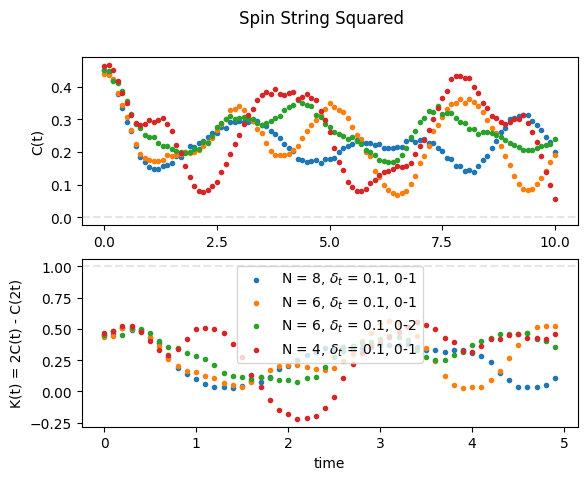

In [7]:

plt_dta = [[8, 10, .1,1 , 'SC2'],[6, 10, .1,1 , 'SC2'],[6, 10, .1,2 , 'SC2'],[4, 10, .1,1 , 'SC2']]

fig, ax = plt.subplots(2)

for i in plt_dta:
    num_sites, time, delta, chain_end, measure = i 

    csv_path = os.getcwd() + "/data/" + "L"+str(num_sites) + 'time'+ str(time) + 'd' + str( delta) +str(measure) + '0_' + str(chain_end) + '.csv'


    with open(csv_path, newline='') as f:
        reader = csv.reader(f)
        [time_range, dta] = [[float(x) for x in row] for row in reader]
    
    half_len = len(dta)//2
    dta_K = [2 * dta[j] - dta[2 * j] for j in range(half_len) ]

    ax[1].scatter(time_range[:half_len]  , dta_K ,  marker= ".", label = "N = " + str(num_sites) + ", $\\delta_t$ = " + str(delta) + ", 0-" + str(chain_end), zorder = 3)
    ax[0].scatter(time_range  , dta ,  marker= ".", label = "N = " + str(num_sites) + ", $\\delta_t$ = " + str(delta) , zorder = 3)
    

#results from hardware
#ax.errorbar(phases / np.pi , chsh1_est, yerr = errors1,fmt = "o-", label = "CHSH1", zorder = 3)


#classical bound
ax[0].axhline( y=0, color="0.9", linestyle = "--")
ax[1].axhline( y=1, color="0.9", linestyle = "--")

#quantum bound
#ax.fill_between(time_range, 1,1.5, color = "0.6", alpha = 0.7)


fig.suptitle("Spin String Squared")
ax[0].xaxis.set_major_locator(tck.MultipleLocator(base = 2.5))
ax[1].xaxis.set_major_locator(tck.MultipleLocator(base = 1))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
ax[1].set(ylabel = "K(t) = 2C(t) - C(2t)")
plt.title("")
plt.legend()

plt.show


In [8]:
#Save plot
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\SpinStringSquared.png")


In [27]:
plt_dta = [ [4,80,.1, 'WM']]


for i in plt_dta:
    num_sites, time, delta, measure = i 

    csv_path = os.getcwd() + "/data/" + "L"+str(num_sites) + 'time'+ str(time) + 'd' + str( delta) +str(measure) + '.csv'


    with open(csv_path, newline='') as f:
        reader = csv.reader(f)
        [time_range, dta] = [[float(x) for x in row] for row in reader]

    half_len = len(dta)//2
    dta_K = [2 * dta[j] - dta[2 * j] for j in range(half_len) ]


max(dta_K)
   

0.9912866706458524